In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Amplitude-Only Gated Attention — Kaggle Notebook                          ║
# ║  New model: MCLDNN-Attention-Amp-Lite  (no signed delta_A)       ║
# ║  Comparison: Normal | Cost-Sensitive | QAM-Shifted | Amp-Lite             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── CELL 1 ─────────────────────────────────────────────────────────────────────
# Setup: clone/pull repo, verify all required files are present before running.
import os, sys, subprocess

REPO_URL = 'https://github.com/akshlabh/amr-5-class.git'
WORK_DIR = '/kaggle/working/amr-5-class'
DATASET  = '/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'

if os.path.exists(WORK_DIR):
    subprocess.run(['git', '-C', WORK_DIR, 'pull'], check=True)
else:
    subprocess.run(['git', 'clone', REPO_URL, WORK_DIR], check=True)

os.chdir(WORK_DIR)
sys.path.insert(0, WORK_DIR)

required = [
    # src files
    'src/dataset.py',
    'src/train.py',
    'src/models/mcldnn_attention.py',
    'src/models/mcldnn_attention_amp.py',
    'src/models/mcldnn_attention_amp_lite.py',
    'src/losses/cost_sensitive.py',
    # configs
    'configs/exp_5class_attention.yaml',
    'configs/exp_5class_attention_amp.yaml',
    'configs/exp_5class_attention_amp_lite.yaml',
    'configs/exp_5class_attention_qam_shifted_cost.yaml',
    # pre-trained weights from previous runs
    'experiments/5class_attention/checkpoints/best_model.weights.h5',
    'experiments/5class_attention_costsensitive/checkpoints/best_model.weights.h5',
    'experiments/5class_attention_qam_shifted_cost/checkpoints/best_model.weights.h5',
]

ok = True
for p in required:
    exists = os.path.exists(p)
    if not exists: ok = False
    print(f"  {'✓' if exists else '✗ MISSING'}  {p}")

if not ok:
    raise RuntimeError("Missing files above — push to GitHub first.")
print("\nAll required files present ✓")




Already up to date.
  ✓  src/dataset.py
  ✓  src/train.py
  ✓  src/models/mcldnn_attention.py
  ✓  src/models/mcldnn_attention_amp.py
  ✓  src/models/mcldnn_attention_amp_lite.py
  ✓  src/losses/cost_sensitive.py
  ✓  configs/exp_5class_attention.yaml
  ✓  configs/exp_5class_attention_amp.yaml
  ✓  configs/exp_5class_attention_amp_lite.yaml
  ✓  configs/exp_5class_attention_qam_shifted_cost.yaml
  ✓  experiments/5class_attention/checkpoints/best_model.weights.h5
  ✓  experiments/5class_attention_costsensitive/checkpoints/best_model.weights.h5
  ✓  experiments/5class_attention_qam_shifted_cost/checkpoints/best_model.weights.h5

All required files present ✓


In [4]:
# ?? CELL 2 ?????????????????????????????????????????????????????????????????????
# Sanity check: verify amp-lite feature extraction and model builds correctly.
# Amp-lite uses 5 inputs:
#   [IQ, I, Q, AmpSeq(128,7), AmpGlobal(7)]
# It removes signed ?A(t) and keeps |?A(t)| + boundary/PAR features.
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
import keras
keras.mixed_precision.set_global_policy('float32')
print(f"Keras policy: {keras.mixed_precision.global_policy()}")

import numpy as np
from src.features.signal_features import (
    estimate_qam16_amplitude_boundary,
    extract_amplitude_peak_lite_features,
)
from src.models.mcldnn_attention_amp_lite import (
    build_mcldnn_attention_amp_lite,
    build_mcldnn_attention_amp_lite_extractor,
)

CLASSES_CHECK = ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']

np.random.seed(42)
X_fake = np.random.randn(8, 2, 128).astype('float32')
y_idx = np.array([3, 3, 3, 3, 4, 4, 0, 1])
Y_fake = np.eye(5, dtype='float32')[y_idx]

T_qam16 = estimate_qam16_amplitude_boundary(
    X_fake,
    Y_fake,
    CLASSES_CHECK,
    quantile=95.0,
)
amp_seq, amp_global = extract_amplitude_peak_lite_features(X_fake, T_qam16)

print(f"QAM16 boundary T       : {T_qam16:.6f}  (synthetic sanity value)")
print(f"Amp-lite sequence shape: {amp_seq.shape}    (expect (8, 128, 7))")
print(f"Amp global shape       : {amp_global.shape}  (expect (8, 7))")
assert amp_seq.shape == (8, 128, 7), f"Wrong amp_seq shape: {amp_seq.shape}"
assert amp_global.shape == (8, 7), f"Wrong amp_global shape: {amp_global.shape}"

A          = amp_seq[:, :, 0]
A2         = amp_seq[:, :, 1]
abs_dA     = amp_seq[:, :, 2]
exceed     = amp_seq[:, :, 3]
excess     = amp_seq[:, :, 4]
rel_excess = amp_seq[:, :, 5]
excess_pow = amp_seq[:, :, 6]

print(f"A(t) range              : [{A.min():.3f}, {A.max():.3f}]  (expect >= 0)")
print(f"A?(t) range             : [{A2.min():.3f}, {A2.max():.3f}]  (expect >= 0)")
print(f"|?A(t)| range           : [{abs_dA.min():.3f}, {abs_dA.max():.3f}]  (expect >= 0)")
print(f"exceed range            : [{exceed.min():.1f}, {exceed.max():.1f}]  (expect 0/1)")
print(f"excess range            : [{excess.min():.3f}, {excess.max():.3f}]  (expect >= 0)")
print(f"relative excess range   : [{rel_excess.min():.3f}, {rel_excess.max():.3f}]  (expect >= 0)")
print(f"excess power range      : [{excess_pow.min():.3f}, {excess_pow.max():.3f}]  (expect >= 0)")
print(f"global feature min/max  : [{amp_global.min():.3f}, {amp_global.max():.3f}]  (finite)")

assert A.min() >= 0
assert A2.min() >= 0
assert abs_dA.min() >= 0
assert set(np.unique(exceed).tolist()).issubset({0.0, 1.0})
assert excess.min() >= 0 and rel_excess.min() >= 0 and excess_pow.min() >= 0
assert np.isfinite(amp_seq).all() and np.isfinite(amp_global).all()

model_lite = build_mcldnn_attention_amp_lite(classes=5)
print(f"\nModel params: {model_lite.count_params():,}")
assert model_lite.count_params() < 300_000, "Exceeds 300k param limit"
print("Under 300k  : ?")

d1 = np.zeros((4, 2, 128, 1), 'float32')
d2 = np.zeros((4, 128, 1),    'float32')
d3 = np.zeros((4, 128, 1),    'float32')
d4 = np.zeros((4, 128, 7),    'float32')  # AmpSeq-lite
d5 = np.zeros((4, 7),         'float32')  # AmpGlobal / PAR stats

out = model_lite.predict([d1, d2, d3, d4, d5], verbose=0)
assert out.shape == (4, 5), f"Wrong output: {out.shape}"
print(f"Output shape: {out.shape} ?")

ext = build_mcldnn_attention_amp_lite_extractor(classes=5)
s, w = ext.predict([d1, d2, d3, d4, d5], verbose=0)
assert s.shape == (4, 5) and w.shape == (4, 4, 124, 124)
print(f"Extractor: softmax={s.shape} attn={w.shape} ?")
del model_lite, ext
print("\nAll checks PASSED ?")


Keras policy: <DTypePolicy "float32">
QAM16 boundary T       : 1.978517  (synthetic sanity value)
Amp-lite sequence shape: (8, 128, 7)    (expect (8, 128, 7))
Amp global shape       : (8, 7)  (expect (8, 7))
A(t) range              : [0.053, 3.208]  (expect >= 0)
A?(t) range             : [0.003, 10.292]  (expect >= 0)
|?A(t)| range           : [0.000, 2.744]  (expect >= 0)
exceed range            : [0.0, 1.0]  (expect 0/1)
excess range            : [0.000, 1.230]  (expect >= 0)
relative excess range   : [0.000, 0.621]  (expect >= 0)
excess power range      : [0.000, 0.386]  (expect >= 0)
global feature min/max  : [0.008, 2.469]  (finite)

Model params: 276,509
Under 300k  : ?
Output shape: (4, 5) ?
Extractor: softmax=(4, 5) attn=(4, 4, 124, 124) ?

All checks PASSED ?


In [5]:
# ── CELL 3 ─────────────────────────────────────────────────────────────────────
# Train amp-lite gated model. Uses ! so epoch logs stream live.
# Expected ~30-60 min on P100. Watch first 5 epochs —
# if accuracy stays at 0.20 the float32 policy is missing from train.py.
import os
DATASET = '/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'
os.chdir('/kaggle/working/amr-5-class')

print("=" * 65)
print("  Training: MCLDNN-Attention-Amp-Lite (no signed delta_A)")
print("  Config  : configs/exp_5class_attention_amp_lite.yaml")
print("=" * 65)

!python src/train.py \
    --config configs/exp_5class_attention_amp_lite.yaml \
    --datasetpath {DATASET}

ckpt_amp = 'experiments/5class_attention_amp_lite/checkpoints/best_model.weights.h5'
if os.path.exists(ckpt_amp):
    print(f"\n✓ Saved: {ckpt_amp}  ({os.path.getsize(ckpt_amp)/1e6:.1f} MB)")
else:
    raise RuntimeError(f"Checkpoint not found: {ckpt_amp}")




  Training: MCLDNN-Attention-Amp-Lite (no signed delta_A)
  Config  : configs/exp_5class_attention_amp_lite.yaml
2026-06-28 18:58:26.393146: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782673106.417334     256 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782673106.424828     256 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782673106.442541     256 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782673106.442573     256 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the sa

In [16]:
# ── CELL 4 ─────────────────────────────────────────────────────────────────────
# Load all 4 models + full dataset.
# amp-lite inputs = 5 tensors (no phase): IQ, I, Q, AmpSeqLite, AmpGlobal.
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.metrics import confusion_matrix as sk_cm

from src.dataset import load_data, FIVE_CLASS
from src.models.mcldnn_attention import build_mcldnn_attention
from src.models.mcldnn_attention_amp_lite import build_mcldnn_attention_amp_lite
from src.features.signal_features import (
    estimate_qam16_amplitude_boundary,
    extract_amplitude_peak_lite_features,
)
from src.losses.cost_sensitive import build_cost_matrix, CostSensitiveCrossEntropy

os.makedirs('experiments/comparison_amp_lite/figures', exist_ok=True)
os.makedirs('experiments/comparison_amp_lite/results',  exist_ok=True)

CLASSES = ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']

# ── helpers ───────────────────────────────────────────────────────────────────
def make_base_inputs(X):
    return [np.expand_dims(X, 3).astype('float32'),
            np.expand_dims(X[:,0,:], 2).astype('float32'),
            np.expand_dims(X[:,1,:], 2).astype('float32')]

def make_amp_inputs(X, qam16_boundary):
    amp_seq, amp_global = extract_amplitude_peak_lite_features(
        X,
        qam16_boundary=qam16_boundary,
    )
    return make_base_inputs(X) + [amp_seq, amp_global]

# ── load data ─────────────────────────────────────────────────────────────────
print("Loading full dataset (all 20 SNRs) ...")
(mods, snrs, lbl), \
(X_train, Y_train), (X_val, Y_val), (X_test, Y_test), \
(train_idx, val_idx, test_idx) = load_data(DATASET, FIVE_CLASS, seed=2016)

test_SNRs = np.array([lbl[test_idx[j]][1] for j in range(len(test_idx))])
ALL_SNRS  = sorted(set(test_SNRs))
print(f"Test samples : {len(Y_test)}  |  SNRs : {ALL_SNRS}")

# IMPORTANT: same as train.py. Estimate QAM16 boundary from training split only.
QAM16_BOUNDARY = estimate_qam16_amplitude_boundary(
    X_train,
    Y_train,
    CLASSES,
    quantile=95.0,
)
print(f"QAM16 amplitude boundary T={QAM16_BOUNDARY:.6f} (train-only 95th percentile)")

inp_test     = make_base_inputs(X_test)
inp_test_amp = make_amp_inputs(X_test, QAM16_BOUNDARY)
print(f"Amp-lite test inputs: AmpSeqLite={inp_test_amp[3].shape}, AmpGlobal={inp_test_amp[4].shape}")

# ── load models ───────────────────────────────────────────────────────────────
print("\nLoading models ...")

m1 = build_mcldnn_attention(classes=5)
m1.load_weights('experiments/5class_attention/checkpoints/best_model.weights.h5')
print(f"  [1] Normal Attention     params={m1.count_params():,}")

C      = build_cost_matrix(CLASSES,
                           [('QAM16','QAM64'),('QAM64','QAM16')],
                           alpha=1.5,
                           correct_class_costs={'QAM16':-1.0,'QAM64':-1.0})
loss_cs = CostSensitiveCrossEntropy(C, label_smoothing=0.1)

m2 = build_mcldnn_attention(classes=5)
m2.compile(loss=loss_cs, optimizer='adam', metrics=['accuracy'])
m2.load_weights('experiments/5class_attention_costsensitive/checkpoints/best_model.weights.h5')
print(f"  [2] Cost-Sensitive       params={m2.count_params():,}")

m3 = build_mcldnn_attention(classes=5)
m3.compile(loss=loss_cs, optimizer='adam', metrics=['accuracy'])
m3.load_weights('experiments/5class_attention_qam_shifted_cost/checkpoints/best_model.weights.h5')
print(f"  [3] QAM-Shifted Cost     params={m3.count_params():,}")

m4 = build_mcldnn_attention_amp_lite(classes=5)
m4.load_weights('experiments/5class_attention_amp_lite/checkpoints/best_model.weights.h5')
print(f"  [4] Amp-Lite/PAR Attention  params={m4.count_params():,}")

# (name, model, inputs, plot_color)
MODELS = [
    ('Normal Attn',        m1, inp_test,     '#1f77b4'),
    ('Cost-Sensitive',     m2, inp_test,     '#ff7f0e'),
    ('QAM-Shifted Cost',   m3, inp_test,     '#2ca02c'),
    ('Amp-Lite/PAR Attn',     m4, inp_test_amp, '#d62728'),
]
col_map = {n: n.lower().replace(' ','_').replace('-','_') for n,_,_,_ in MODELS}
print("\nAll models loaded ✓")




Loading full dataset (all 20 SNRs) ...
[dataset] Loading 5 classes: ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
[dataset] SNR range: -20 dB to 18 dB  (20 levels)
[dataset] After normalization — train RMS: 1.0000  (should be ≈1.0)
[dataset] Split: 60000 train | 20000 val | 20000 test samples
Test samples : 20000  |  SNRs : [np.int64(-20), np.int64(-18), np.int64(-16), np.int64(-14), np.int64(-12), np.int64(-10), np.int64(-8), np.int64(-6), np.int64(-4), np.int64(-2), np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18)]
QAM16 amplitude boundary T=1.797903 (train-only 95th percentile)
Amp-lite test inputs: AmpSeqLite=(20000, 128, 7), AmpGlobal=(20000, 7)

Loading models ...
  [1] Normal Attention     params=244,341


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 66 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  [2] Cost-Sensitive       params=244,341
  [3] QAM-Shifted Cost     params=244,341
  [4] Amp-Lite/PAR Attention  params=276,509

All models loaded ✓


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 90 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [7]:
# ── CELL 5 ─────────────────────────────────────────────────────────────────────
# Per-SNR accuracy table for all 4 models across all 20 SNR levels.
print(f"\n{'='*80}")
print(f"  {'SNR':>5}  {'Normal':>10}  {'CostSens':>10}  "
      f"{'QAMShift':>10}  {'AmpLite':>10}")
print(f"  {'─'*58}")

rows = []
for snr in ALL_SNRS:
    mask = test_SNRs == snr
    row  = {'snr': snr}
    accs = []
    for name, model, inp, _ in MODELS:
        acc = model.evaluate([x[mask] for x in inp],
                             Y_test[mask], verbose=0, batch_size=400)[1]
        row[col_map[name]] = acc
        accs.append(acc)
    rows.append(row)
    print(f"  {snr:>5} dB  "
          + "  ".join(f"{a*100:>9.2f}%" for a in accs))

df = pd.DataFrame(rows)
print(f"  {'─'*58}")
means = {col_map[n]: df[col_map[n]].mean() for n,_,_,_ in MODELS}
print(f"  {'Mean':>5}   "
      + "  ".join(f"{means[col_map[n]]*100:>9.2f}%" for n,_,_,_ in MODELS))
print(f"{'='*80}")

df.to_csv('experiments/comparison_amp_lite/results/all4_per_snr.csv', index=False)
print("\n[SAVED] experiments/comparison_amp_lite/results/all4_per_snr.csv")





    SNR      Normal    CostSens    QAMShift     AmpLite
  ──────────────────────────────────────────────────────────
    -20 dB      32.90%      34.40%      33.00%      32.30%
    -18 dB      30.90%      33.20%      32.10%      33.30%
    -16 dB      32.00%      33.40%      33.30%      31.70%
    -14 dB      31.70%      32.30%      33.70%      29.20%
    -12 dB      30.30%      32.60%      31.50%      31.00%
    -10 dB      27.60%      33.10%      29.40%      27.30%
     -8 dB      28.30%      31.00%      29.10%      28.80%
     -6 dB      32.40%      33.90%      33.70%      30.30%
     -4 dB      40.00%      43.60%      45.00%      41.90%
     -2 dB      57.20%      59.00%      59.10%      57.80%
      0 dB      76.00%      73.20%      72.60%      73.60%
      2 dB      83.40%      80.90%      78.10%      81.10%
      4 dB      88.10%      84.30%      79.80%      83.90%
      6 dB      88.80%      86.30%      78.70%      83.90%
      8 dB      90.20%      88.10%      81.00%      86.3

In [8]:
# ── CELL 6 ─────────────────────────────────────────────────────────────────────
# Compute QAM16↔QAM64 and QPSK↔8PSK confusion rates.
# This is the key metric — amp peak/PAR model targets QAM confusion specifically.
qam16 = CLASSES.index('QAM16')
qam64 = CLASSES.index('QAM64')
qpsk  = CLASSES.index('QPSK')
psk8  = CLASSES.index('8PSK')
true  = np.argmax(Y_test, axis=1)

def conf_pair(pred, true, a, b):
    ma = true == a;  mb = true == b
    return ((pred[ma]==b).mean() if ma.sum()>0 else 0.0,
            (pred[mb]==a).mean() if mb.sum()>0 else 0.0)

conf_rows = []
print(f"\n{'Model':<22}  {'QAM16→64':>10}  {'QAM64→16':>10}  "
      f"{'QPSK→8':>8}  {'8PSK→QP':>9}")
print("-" * 68)
for name, model, inp, _ in MODELS:
    pred = np.argmax(model.predict(inp, verbose=0, batch_size=400), axis=1)
    r1,r2 = conf_pair(pred, true, qam16, qam64)
    r3,r4 = conf_pair(pred, true, qpsk,  psk8)
    conf_rows.append({'model':name,
                      'qam16_qam64':r1, 'qam64_qam16':r2,
                      'qpsk_8psk':r3,  '8psk_qpsk':r4})
    print(f"  {name:<20}  {r1*100:>9.2f}%  {r2*100:>9.2f}%  "
          f"{r3*100:>7.2f}%  {r4*100:>8.2f}%")

pd.DataFrame(conf_rows).to_csv(
    'experiments/comparison_amp_lite/results/confusion_pairs.csv', index=False)
print("\n[SAVED] experiments/comparison_amp_lite/results/confusion_pairs.csv")





Model                     QAM16→64    QAM64→16    QPSK→8    8PSK→QP
--------------------------------------------------------------------
  Normal Attn               22.55%      36.80%     8.22%      5.58%
  Cost-Sensitive            16.48%      26.67%    23.80%      8.43%
  QAM-Shifted Cost          17.38%      48.98%    16.68%     10.45%
  Amp-Lite/PAR Attn         30.38%      28.50%    13.45%      8.35%

[SAVED] experiments/comparison_amp_lite/results/confusion_pairs.csv


[SAVED] experiments/comparison_amp_lite/figures/main_4model_comparison.png


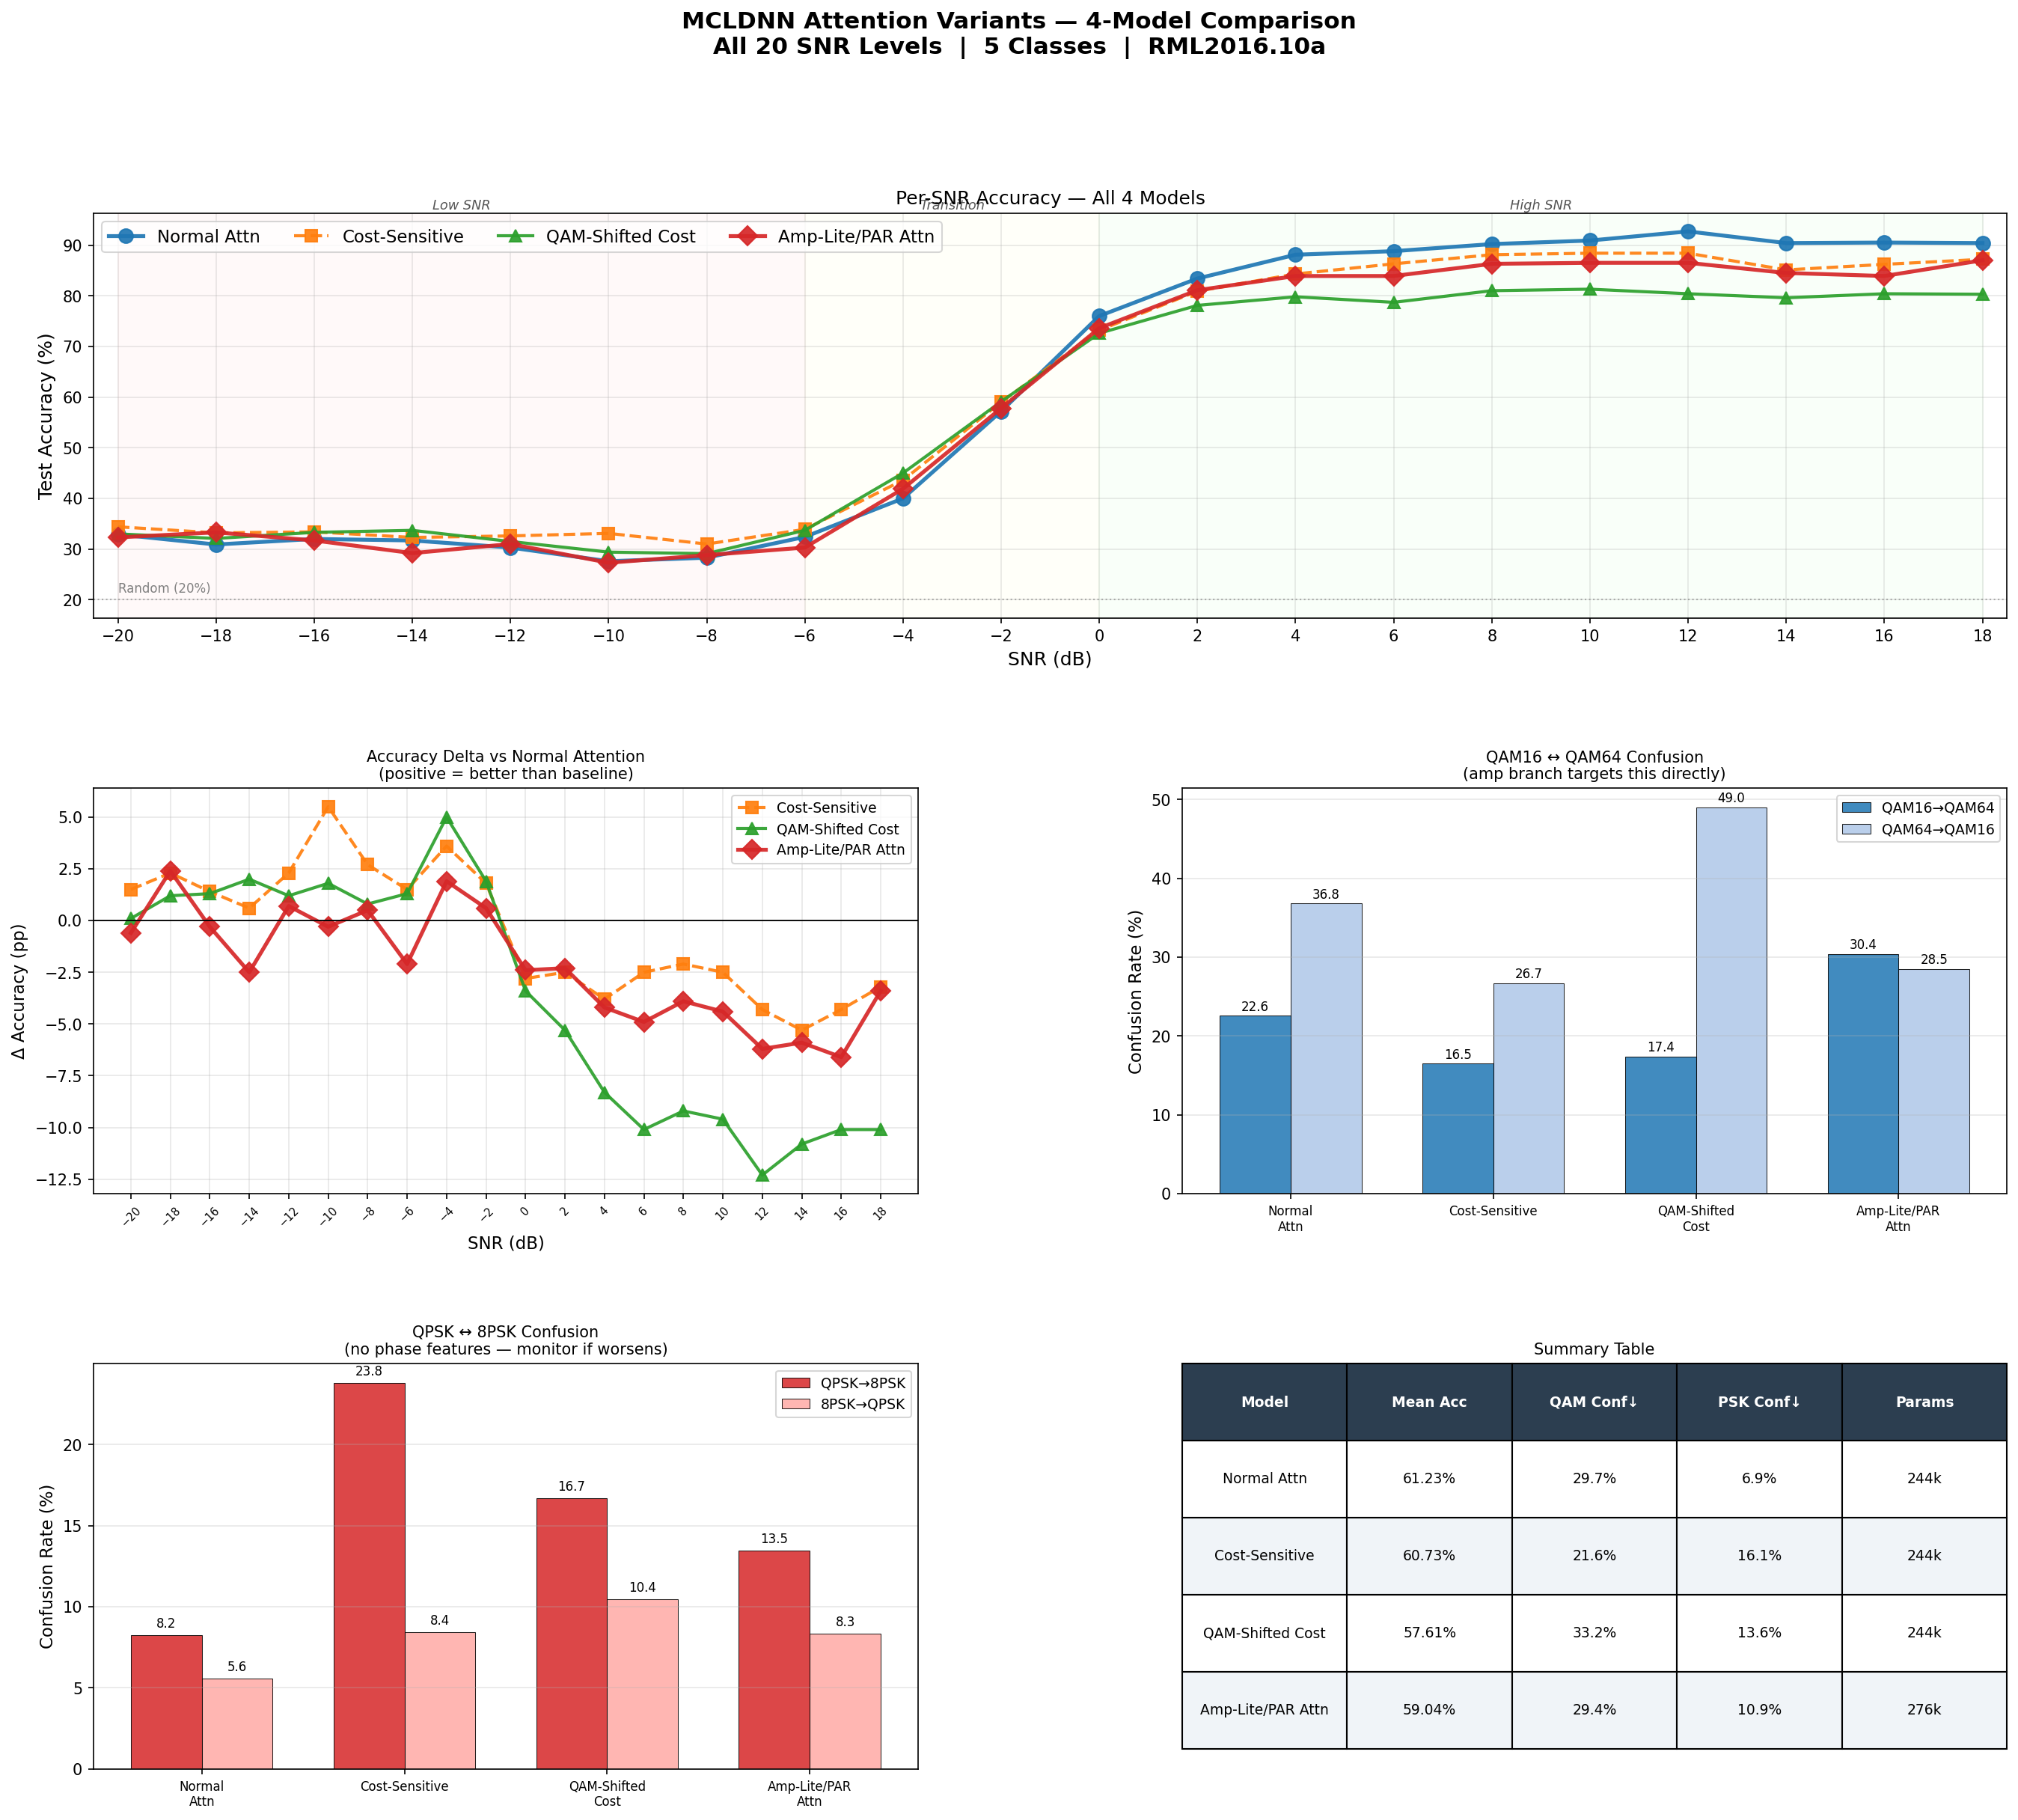

In [9]:
# ── CELL 7 ─────────────────────────────────────────────────────────────────────
# Main 5-panel comparison figure:
#   Panel 1: Accuracy curves all 20 SNRs
#   Panel 2: Delta vs Normal Attention
#   Panel 3: QAM16↔QAM64 confusion bars
#   Panel 4: QPSK↔8PSK confusion bars
#   Panel 5: Summary table
style = {'Normal Attn':      ('o-',  2.5, 9, '#1f77b4'),
         'Cost-Sensitive':   ('s--', 2.0, 8, '#ff7f0e'),
         'QAM-Shifted Cost': ('^-',  2.0, 8, '#2ca02c'),
         'Amp-Lite/PAR Attn':   ('D-',  2.5, 9, '#d62728')}
snr_arr = df['snr'].values

fig = plt.figure(figsize=(22, 18))
fig.suptitle('MCLDNN Attention Variants — 4-Model Comparison\n'
             'All 20 SNR Levels  |  5 Classes  |  RML2016.10a',
             fontsize=15, fontweight='bold')
gs = fig.add_gridspec(3, 2, hspace=0.42, wspace=0.32)

# ── P1: Accuracy curves ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for name, _, _, _ in MODELS:
    mk, lw, ms, col = style[name]
    ax1.plot(snr_arr, df[col_map[name]]*100, mk,
             color=col, linewidth=lw, markersize=ms, label=name, alpha=0.92)
ax1.axhline(20, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax1.text(snr_arr[0], 21.5, 'Random (20%)', fontsize=8, color='gray')
for lo, hi, col2, lbl2 in [(-20,-6,'#fee','Low SNR'),
                            (-6,  0,'#ffe','Transition'),
                            (0,  18,'#efe','High SNR')]:
    ax1.axvspan(lo, hi, color=col2, alpha=0.35, zorder=0)
    ax1.text((lo+hi)/2, 97, lbl2, ha='center', fontsize=8.5,
             color='#555', style='italic')
ax1.set_xlabel('SNR (dB)', fontsize=12); ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Per-SNR Accuracy — All 4 Models', fontsize=12)
ax1.legend(fontsize=11, ncol=4, loc='upper left')
ax1.grid(True, alpha=0.3); ax1.set_xticks(snr_arr)
ax1.set_xlim(snr_arr[0]-0.5, snr_arr[-1]+0.5)

# ── P2: Delta vs Normal Attention ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
base = df[col_map['Normal Attn']]
for name, _, _, _ in MODELS[1:]:
    mk, lw, ms, col = style[name]
    delta = (df[col_map[name]] - base) * 100
    ax2.plot(snr_arr, delta, mk, color=col, linewidth=lw,
             markersize=ms, label=name, alpha=0.92)
ax2.axhline(0, color='black', linewidth=0.9)
ax2.set_xlabel('SNR (dB)', fontsize=11)
ax2.set_ylabel('Δ Accuracy (pp)', fontsize=11)
ax2.set_title('Accuracy Delta vs Normal Attention\n(positive = better than baseline)',
              fontsize=10)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_xticks(snr_arr)
plt.setp(ax2.get_xticklabels(), rotation=45, fontsize=7)

# ── P3: QAM confusion bars ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
x = np.arange(len(conf_rows));  w = 0.35
ax3.bar(x-w/2, [r['qam16_qam64']*100 for r in conf_rows], w,
        label='QAM16→QAM64', color='#1f77b4', alpha=0.85, edgecolor='black', lw=0.5)
ax3.bar(x+w/2, [r['qam64_qam16']*100 for r in conf_rows], w,
        label='QAM64→QAM16', color='#aec7e8', alpha=0.85, edgecolor='black', lw=0.5)
for bars, vals in [(ax3.patches[:len(conf_rows)],
                    [r['qam16_qam64']*100 for r in conf_rows]),
                   (ax3.patches[len(conf_rows):],
                    [r['qam64_qam16']*100 for r in conf_rows])]:
    for bar, v in zip(bars, vals):
        ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v:.1f}', ha='center', va='bottom', fontsize=8)
ax3.set_xticks(x)
ax3.set_xticklabels([r['model'].replace(' ','\n') for r in conf_rows], fontsize=8)
ax3.set_ylabel('Confusion Rate (%)', fontsize=11)
ax3.set_title('QAM16 ↔ QAM64 Confusion\n(amp branch targets this directly)',
              fontsize=10)
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3, axis='y')

# ── P4: PSK confusion bars ────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.bar(x-w/2, [r['qpsk_8psk']*100 for r in conf_rows], w,
        label='QPSK→8PSK', color='#d62728', alpha=0.85, edgecolor='black', lw=0.5)
ax4.bar(x+w/2, [r['8psk_qpsk']*100 for r in conf_rows], w,
        label='8PSK→QPSK', color='#ffaaa5', alpha=0.85, edgecolor='black', lw=0.5)
for bars, vals in [(ax4.patches[:len(conf_rows)],
                    [r['qpsk_8psk']*100 for r in conf_rows]),
                   (ax4.patches[len(conf_rows):],
                    [r['8psk_qpsk']*100 for r in conf_rows])]:
    for bar, v in zip(bars, vals):
        ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v:.1f}', ha='center', va='bottom', fontsize=8)
ax4.set_xticks(x)
ax4.set_xticklabels([r['model'].replace(' ','\n') for r in conf_rows], fontsize=8)
ax4.set_ylabel('Confusion Rate (%)', fontsize=11)
ax4.set_title('QPSK ↔ 8PSK Confusion\n(no phase features — monitor if worsens)',
              fontsize=10)
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3, axis='y')

# ── P5: Summary table ─────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('off')
hdr  = ['Model', 'Mean Acc', 'QAM Conf↓', 'PSK Conf↓', 'Params']
rows_t = []
for i,(name,model,_,_) in enumerate(MODELS):
    r   = conf_rows[i]
    qam = (r['qam16_qam64']+r['qam64_qam16'])/2*100
    psk = (r['qpsk_8psk']+r['8psk_qpsk'])/2*100
    rows_t.append([name,
                   f"{means[col_map[name]]*100:.2f}%",
                   f"{qam:.1f}%",
                   f"{psk:.1f}%",
                   f"{model.count_params()//1000}k"])
tbl = ax5.table(cellText=rows_t, colLabels=hdr,
                cellLoc='center', loc='center', bbox=[0,0.05,1,0.95])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r,c), cell in tbl.get_celld().items():
    if r==0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r%2==0: cell.set_facecolor('#f0f4f8')
ax5.set_title('Summary Table', fontsize=10, pad=6)

p1 = 'experiments/comparison_amp_lite/figures/main_4model_comparison.png'
fig.savefig(p1, dpi=150, bbox_inches='tight')
plt.close(fig)
print(f"[SAVED] {p1}")
display(Image(p1))




[SAVED] experiments/comparison_amp_lite/figures/confusion_4models.png


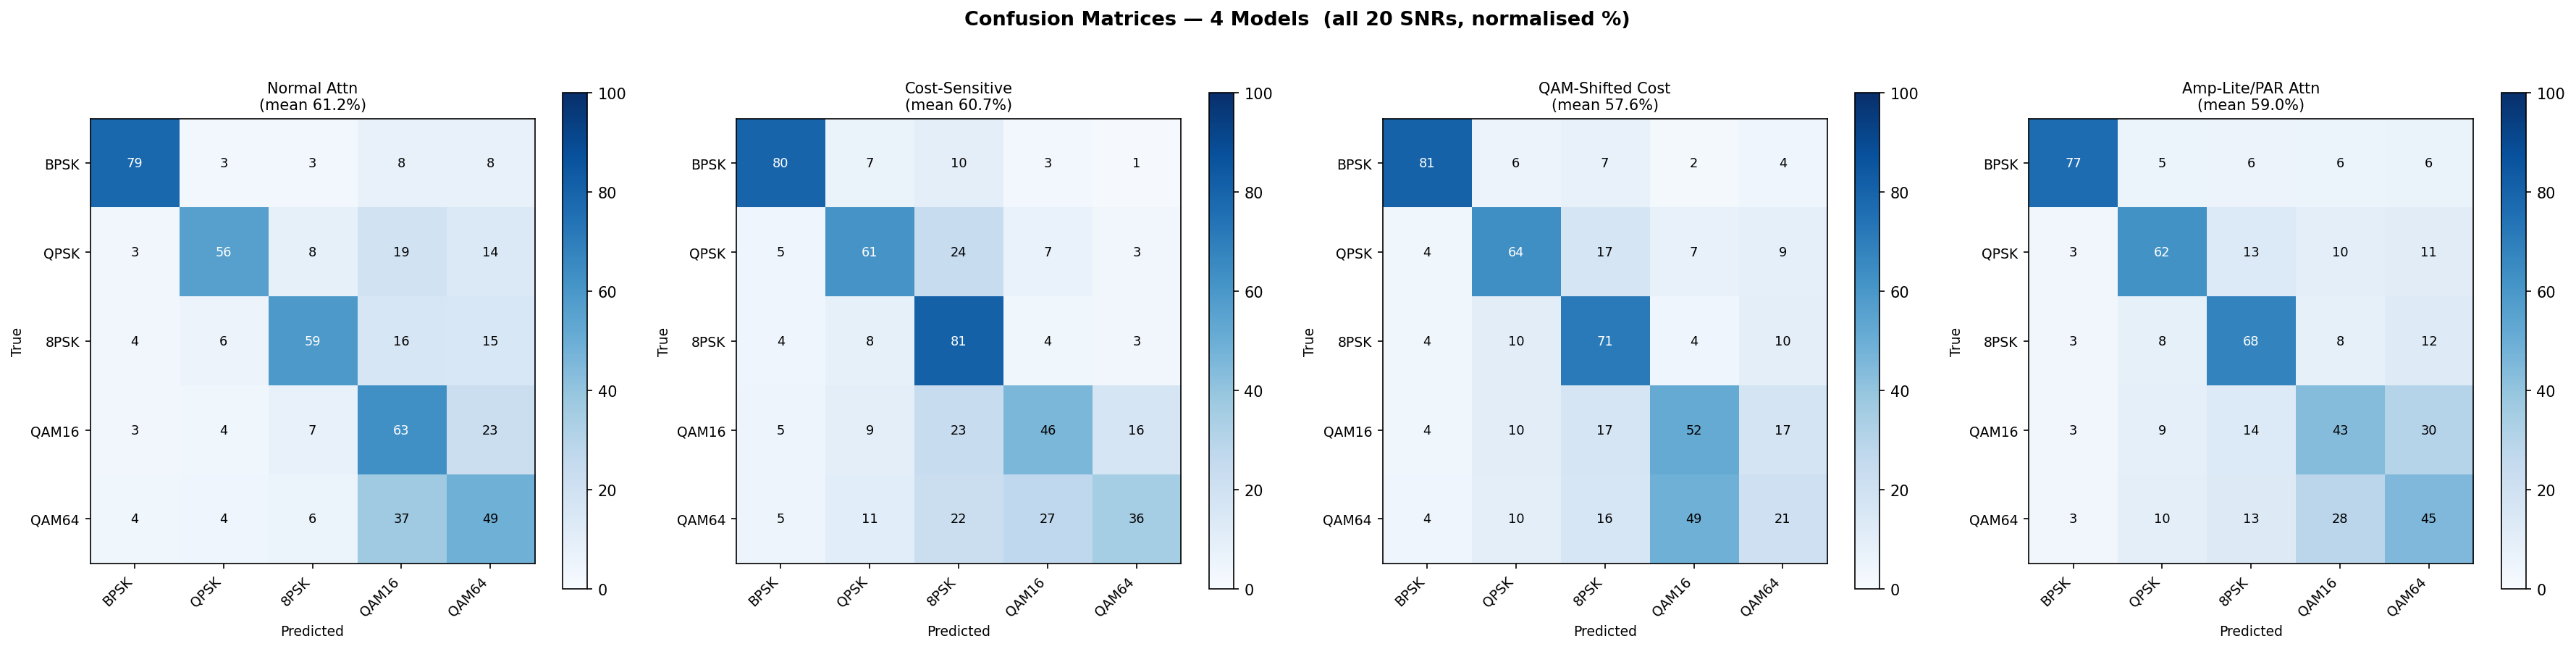

In [10]:
# ── CELL 8 ─────────────────────────────────────────────────────────────────────
# Side-by-side confusion matrices for all 4 models on full test set.
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('Confusion Matrices — 4 Models  (all 20 SNRs, normalised %)',
             fontsize=13, fontweight='bold')

for ax, (name, model, inp, _) in zip(axes, MODELS):
    pred = np.argmax(model.predict(inp, verbose=0, batch_size=400), axis=1)
    cm   = sk_cm(true, pred, normalize='true') * 100
    im   = ax.imshow(cm, cmap='Blues', vmin=0, vmax=100)
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_xticks(range(5)); ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(5)); ax.set_yticklabels(CLASSES, fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('True', fontsize=9)
    ax.set_title(f'{name}\n(mean {means[col_map[name]]*100:.1f}%)', fontsize=10)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{cm[i,j]:.0f}', ha='center', va='center',
                    fontsize=8.5,
                    color='white' if cm[i,j]>55 else 'black')

plt.tight_layout()
p2 = 'experiments/comparison_amp_lite/figures/confusion_4models.png'
fig.savefig(p2, dpi=150, bbox_inches='tight')
plt.close(fig)
print(f"[SAVED] {p2}")
display(Image(p2))




[SAVED] experiments/comparison_amp_lite/figures/regime_breakdown.png


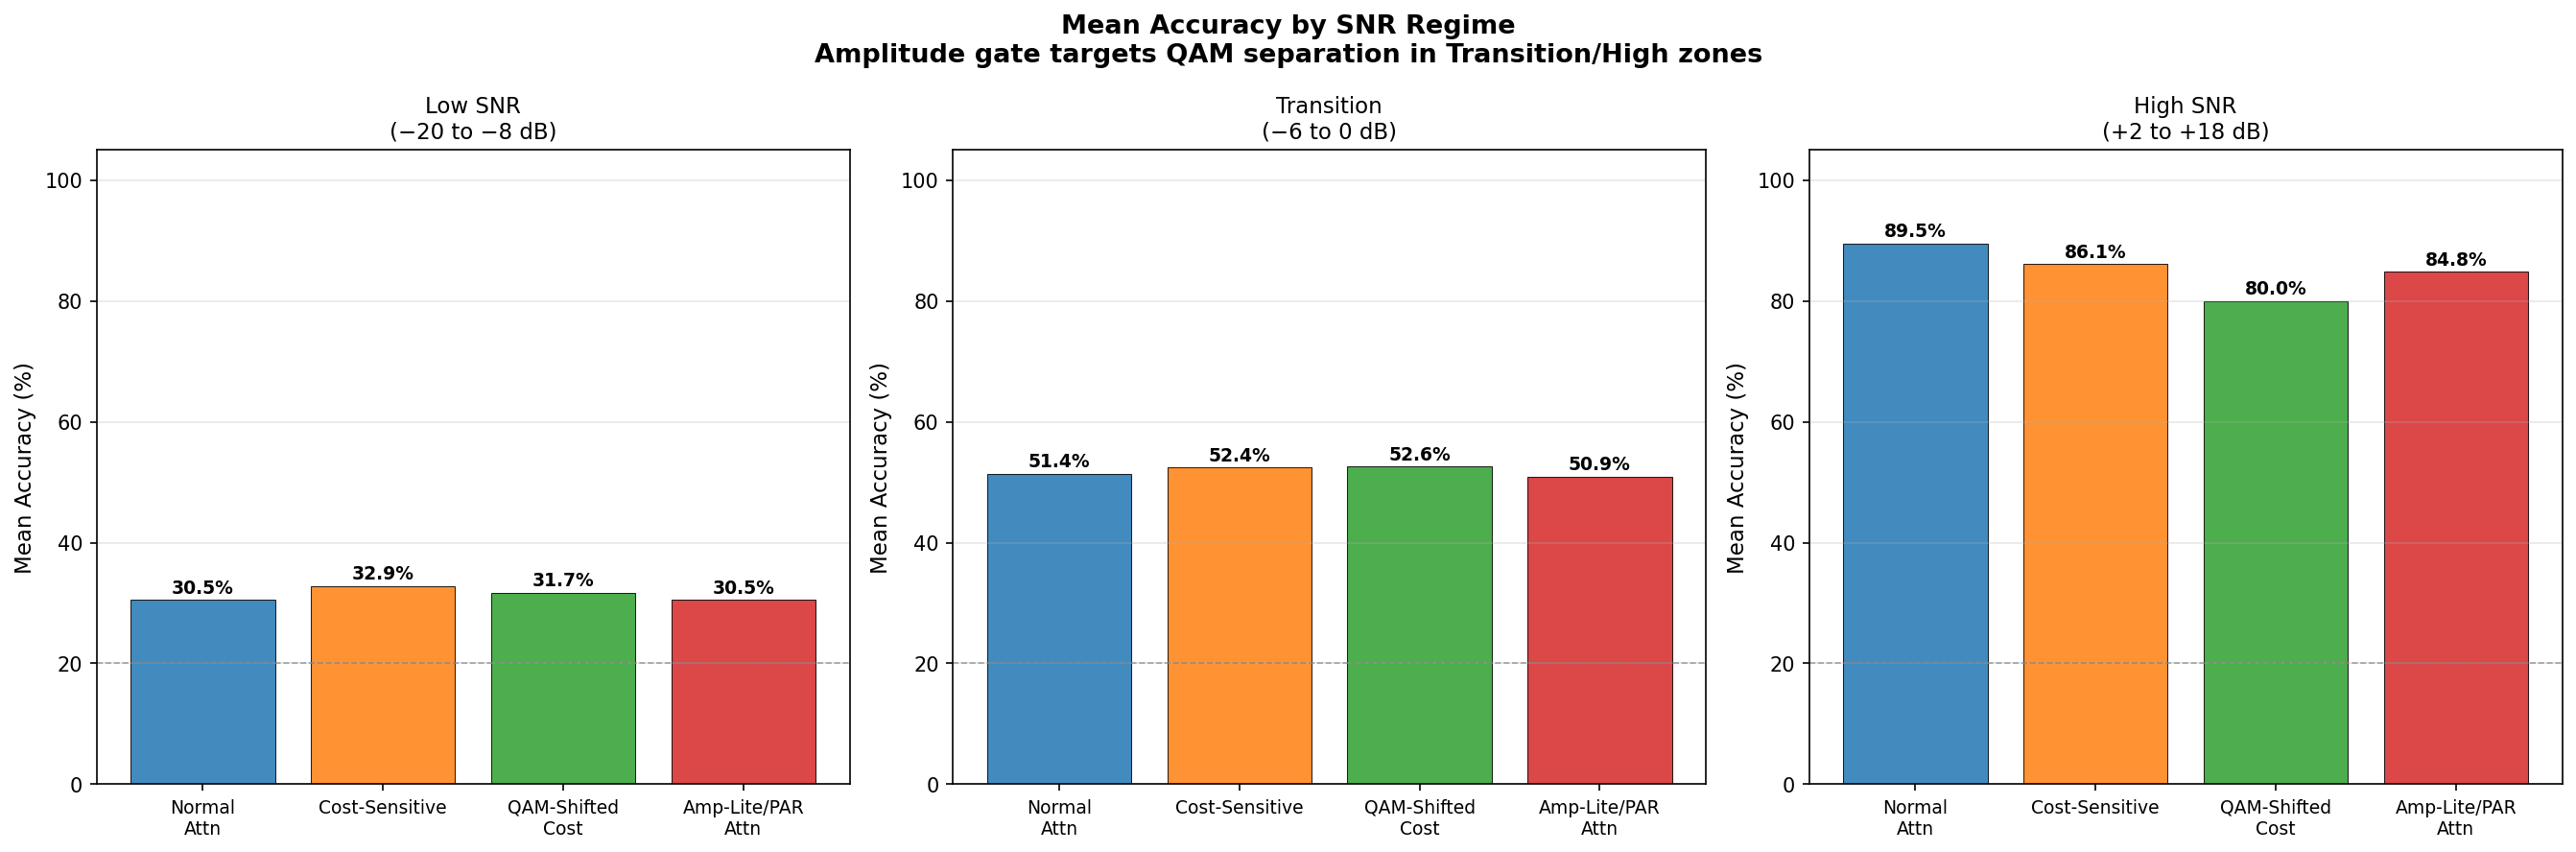

In [11]:
# ── CELL 9 ─────────────────────────────────────────────────────────────────────
# Regime breakdown: mean accuracy in Low / Transition / High SNR zones.
# Amp peak/PAR model expected to help most in Transition zone where A(t) is reliable.
regimes = {
    'Low SNR\n(−20 to −8 dB)':   [s for s in ALL_SNRS if s < -6],
    'Transition\n(−6 to 0 dB)':  [s for s in ALL_SNRS if -6 <= s <= 0],
    'High SNR\n(+2 to +18 dB)':  [s for s in ALL_SNRS if s > 0],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Mean Accuracy by SNR Regime\n'
             'Amplitude gate targets QAM separation in Transition/High zones',
             fontsize=13, fontweight='bold')

for ax, (rlabel, rsnrs) in zip(axes, regimes.items()):
    vals   = [df.loc[df['snr'].isin(rsnrs), col_map[n]].mean()*100
              for n,_,_,_ in MODELS]
    names  = [n for n,_,_,_ in MODELS]
    colors = [style[n][3] for n in names]
    bars   = ax.bar(range(len(names)), vals, color=colors,
                    alpha=0.85, edgecolor='black', lw=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace(' ','\n') for n in names], fontsize=9)
    ax.set_ylabel('Mean Accuracy (%)', fontsize=11)
    ax.set_title(rlabel, fontsize=11)
    ax.set_ylim(0, 105)
    ax.axhline(20, color='gray', linestyle='--', lw=0.8, alpha=0.7)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
p3 = 'experiments/comparison_amp_lite/figures/regime_breakdown.png'
fig.savefig(p3, dpi=150, bbox_inches='tight')
plt.close(fig)
print(f"[SAVED] {p3}")
display(Image(p3))




[SAVED] experiments/comparison_amp_lite/figures/amp_training_history.png


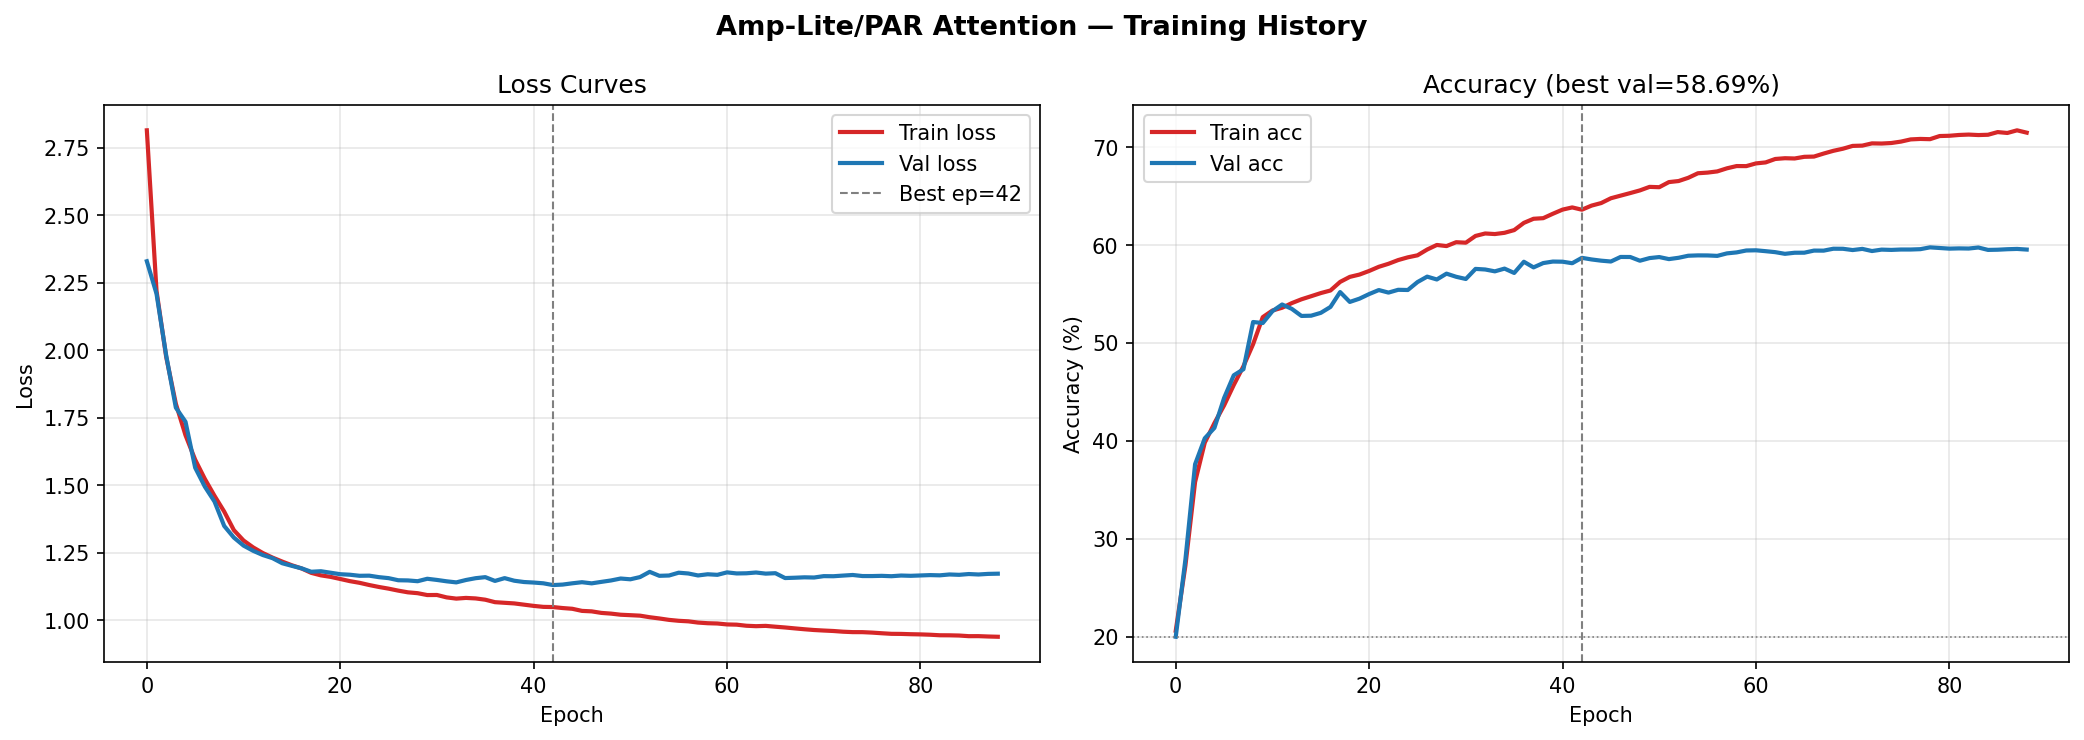


Best epoch : 42
Best val loss : 1.1299
Best val acc  : 58.69%


In [12]:
# ── CELL 10 ────────────────────────────────────────────────────────────────────
# Training history for the amp peak/PAR model.
# Watch for: train-val gap < 15pp, val accuracy > 60%.
log_path = 'experiments/5class_attention_amp_lite/logs/training_log.csv'

if not os.path.exists(log_path):
    print(f"[WARN] {log_path} not found — run Cell 3 first")
else:
    log = pd.read_csv(log_path)
    va  = next((c for c in log.columns if 'val' in c and 'acc' in c), 'val_accuracy')
    ta  = next((c for c in log.columns if 'acc' in c and 'val' not in c), 'accuracy')
    best_e = log['val_loss'].idxmin()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Amp-Lite/PAR Attention — Training History', fontsize=13, fontweight='bold')

    axes[0].plot(log['epoch'], log['loss'],     '#d62728', lw=2, label='Train loss')
    axes[0].plot(log['epoch'], log['val_loss'], '#1f77b4', lw=2, label='Val loss')
    axes[0].axvline(best_e, color='gray', ls='--', lw=1, label=f'Best ep={best_e}')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss Curves'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(log['epoch'], log[ta]*100, '#d62728', lw=2, label='Train acc')
    axes[1].plot(log['epoch'], log[va]*100, '#1f77b4', lw=2, label='Val acc')
    axes[1].axhline(20, color='gray', ls=':', lw=0.8)
    axes[1].axvline(best_e, color='gray', ls='--', lw=1)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'Accuracy (best val={log.loc[best_e,va]*100:.2f}%)')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    p4 = 'experiments/comparison_amp_lite/figures/amp_training_history.png'
    fig.savefig(p4, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"[SAVED] {p4}")
    display(Image(p4))
    print(f"\nBest epoch : {best_e}")
    print(f"Best val loss : {log.loc[best_e,'val_loss']:.4f}")
    print(f"Best val acc  : {log.loc[best_e,va]*100:.2f}%")




[SAVED] experiments/comparison_amp_lite/figures/qam_confusion_per_snr.png


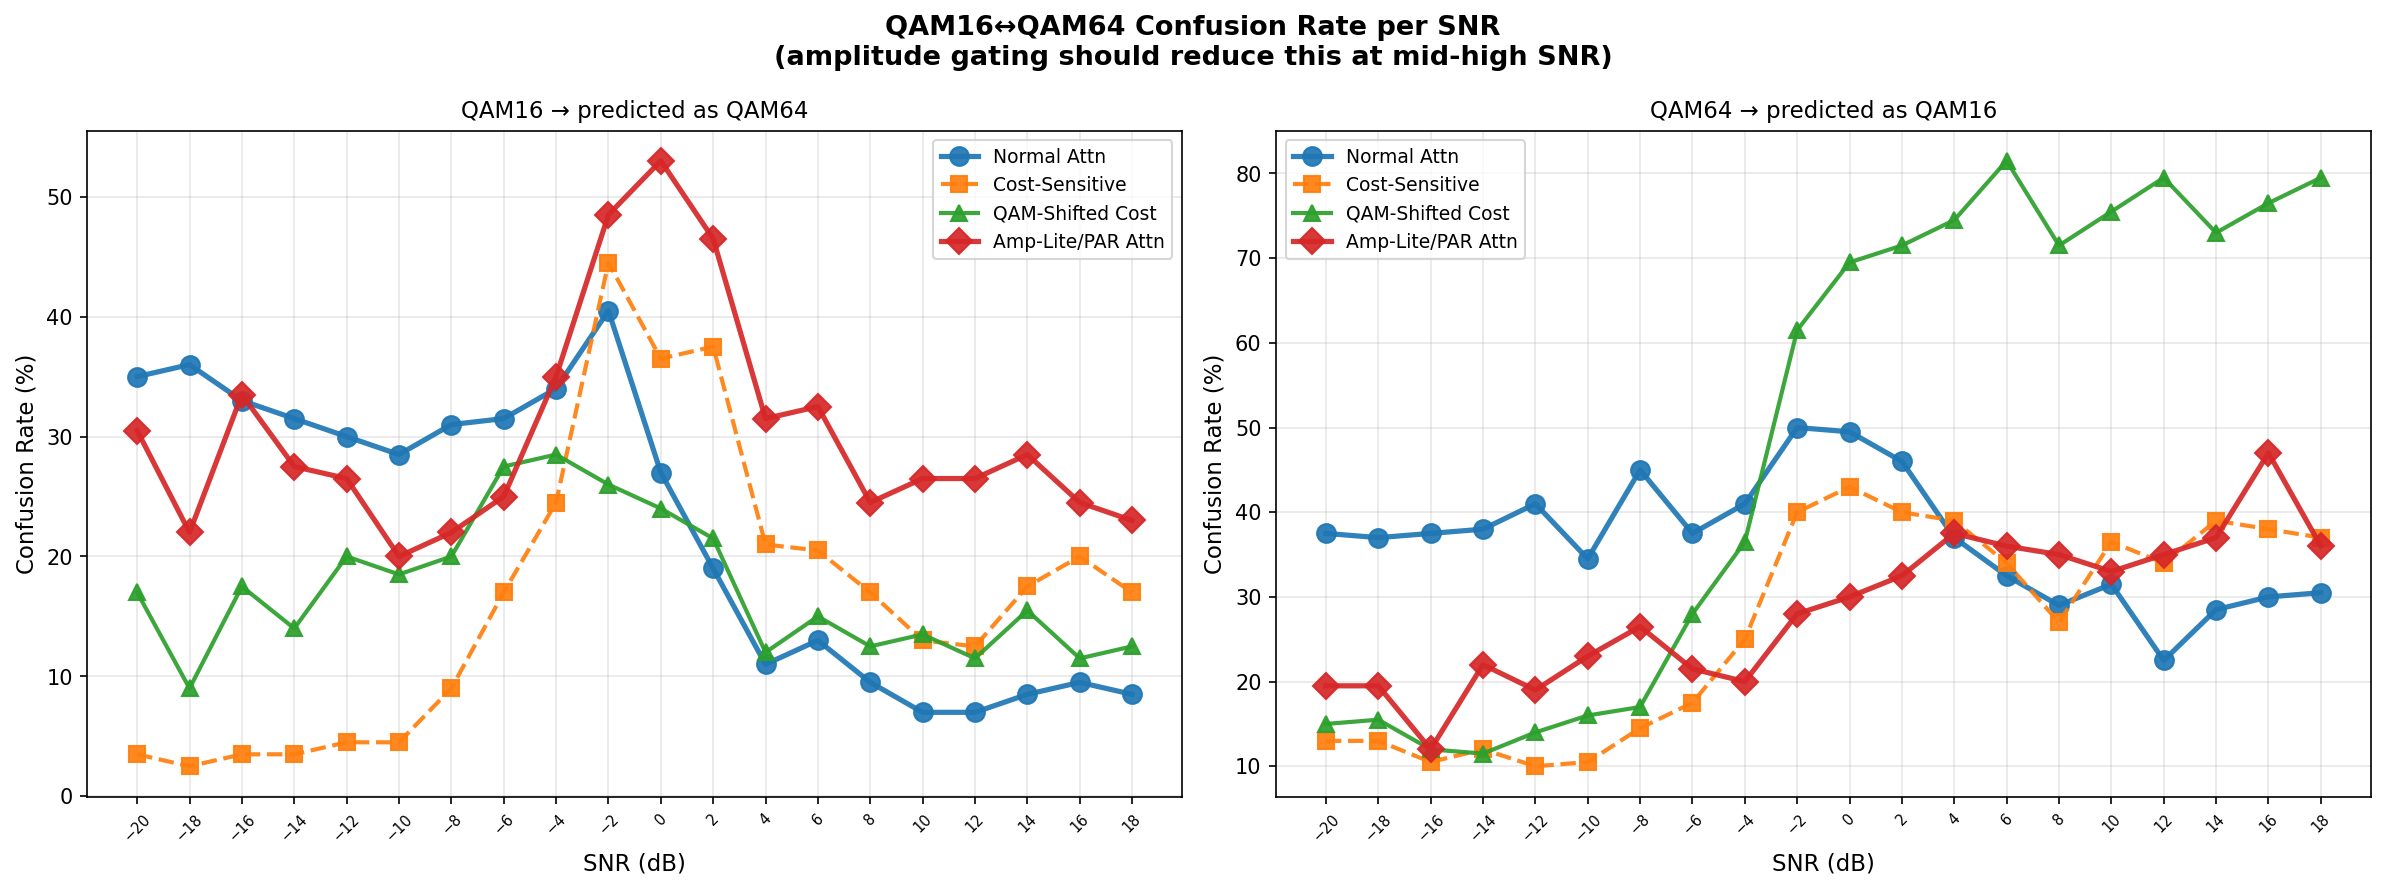

In [13]:
# ── CELL 11 ────────────────────────────────────────────────────────────────────
# Per-SNR QAM confusion rate line plot across all 20 SNRs.
# Shows at which SNR levels the amplitude gate actually reduces confusion.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('QAM16↔QAM64 Confusion Rate per SNR\n'
             '(amplitude gating should reduce this at mid-high SNR)',
             fontsize=13, fontweight='bold')

for ax_i, (true_cls, pred_cls, title) in enumerate([
    (qam16, qam64, 'QAM16 → predicted as QAM64'),
    (qam64, qam16, 'QAM64 → predicted as QAM16'),
]):
    ax = axes[ax_i]
    for name, model, inp, color in MODELS:
        pred_all = np.argmax(model.predict(inp, verbose=0, batch_size=400), axis=1)
        rates = []
        for snr in ALL_SNRS:
            mask_snr   = test_SNRs == snr
            true_snr   = true[mask_snr]
            pred_snr   = pred_all[mask_snr]
            mask_class = true_snr == true_cls
            rate = (pred_snr[mask_class] == pred_cls).mean() if mask_class.sum()>0 else 0
            rates.append(rate * 100)
        mk, lw, ms, col = style[name]
        ax.plot(ALL_SNRS, rates, mk, color=col, linewidth=lw,
                markersize=ms, label=name, alpha=0.92)
    ax.set_xlabel('SNR (dB)', fontsize=11); ax.set_ylabel('Confusion Rate (%)', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ax.set_xticks(ALL_SNRS)
    plt.setp(ax.get_xticklabels(), rotation=45, fontsize=7)

plt.tight_layout()
p5 = 'experiments/comparison_amp_lite/figures/qam_confusion_per_snr.png'
fig.savefig(p5, dpi=150, bbox_inches='tight')
plt.close(fig)
print(f"[SAVED] {p5}")
display(Image(p5))




In [14]:
# ── CELL 12 ────────────────────────────────────────────────────────────────────
# Print full numerical results table for the report.
print("\n" + "="*80)
print("  COMPLETE PER-SNR RESULTS TABLE")
print("="*80)
print(f"  {'SNR':>5}  {'Normal':>10}  {'CostSens':>10}  "
      f"{'QAMShift':>10}  {'AmpLite':>10}  {'Best':>14}")
print("  " + "─"*72)

for _, row in df.iterrows():
    vs   = {n: row[col_map[n]] for n,_,_,_ in MODELS}
    best = max(vs, key=vs.get)
    print(f"  {int(row['snr']):>5} dB  "
          + "  ".join(f"{v*100:>9.2f}%" for v in vs.values())
          + f"  {best:>10} ({vs[best]*100:.1f}%)")

print("  " + "─"*72)
print(f"  {'Mean':>5}   "
      + "  ".join(f"{means[col_map[n]]*100:>9.2f}%" for n,_,_,_ in MODELS))
print("="*80)





  COMPLETE PER-SNR RESULTS TABLE
    SNR      Normal    CostSens    QAMShift     AmpLite            Best
  ────────────────────────────────────────────────────────────────────────
    -20 dB      32.90%      34.40%      33.00%      32.30%  Cost-Sensitive (34.4%)
    -18 dB      30.90%      33.20%      32.10%      33.30%  Amp-Lite/PAR Attn (33.3%)
    -16 dB      32.00%      33.40%      33.30%      31.70%  Cost-Sensitive (33.4%)
    -14 dB      31.70%      32.30%      33.70%      29.20%  QAM-Shifted Cost (33.7%)
    -12 dB      30.30%      32.60%      31.50%      31.00%  Cost-Sensitive (32.6%)
    -10 dB      27.60%      33.10%      29.40%      27.30%  Cost-Sensitive (33.1%)
     -8 dB      28.30%      31.00%      29.10%      28.80%  Cost-Sensitive (31.0%)
     -6 dB      32.40%      33.90%      33.70%      30.30%  Cost-Sensitive (33.9%)
     -4 dB      40.00%      43.60%      45.00%      41.90%  QAM-Shifted Cost (45.0%)
     -2 dB      57.20%      59.00%      59.10%      57.80%  QAM-S

In [15]:
# ── CELL 13 ────────────────────────────────────────────────────────────────────
# Zip all outputs: amp experiment results + comparison + source files.
import zipfile
from datetime import datetime

ts       = datetime.now().strftime('%Y%m%d_%H%M')
zip_path = f'/kaggle/working/amr_amp_lite_{ts}.zip'

INCLUDE = [
    'experiments/5class_attention_amp_lite',   # weights, logs, results
    'experiments/comparison_amp_lite',         # all figures and CSVs
    'src/models/mcldnn_attention_amp_lite.py',
    'configs/exp_5class_attention_amp_lite.yaml',
]
EXTS = {'.h5','.keras','.png','.csv','.txt','.yaml','.py','.json','.npy'}

print(f"Creating: {zip_path}\n")
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for item in INCLUDE:
        if not os.path.exists(item):
            print(f"  [skip] {item}"); continue
        if os.path.isfile(item):
            arc = os.path.relpath(item, WORK_DIR)
            zf.write(item, arc); print(f"  + {arc}")
        else:
            for root, _, files in os.walk(item):
                for fname in files:
                    if os.path.splitext(fname)[1] in EXTS:
                        fp  = os.path.join(root, fname)
                        arc = os.path.relpath(fp, WORK_DIR)
                        zf.write(fp, arc); print(f"  + {arc}")

print(f"\n[DONE] {zip_path}  ({os.path.getsize(zip_path)/1e6:.1f} MB)")
print("Download: Kaggle → Output panel (right side) ✓")

Creating: /kaggle/working/amr_amp_lite_20260628_1909.zip

  + experiments/5class_attention_amp_lite/logs/val_loss.txt
  + experiments/5class_attention_amp_lite/logs/val_acc.txt
  + experiments/5class_attention_amp_lite/logs/training_log.csv
  + experiments/5class_attention_amp_lite/logs/train_acc.txt
  + experiments/5class_attention_amp_lite/logs/total_loss.png
  + experiments/5class_attention_amp_lite/logs/total_acc.png
  + experiments/5class_attention_amp_lite/logs/train_loss.txt
  + experiments/5class_attention_amp_lite/checkpoints/best_model.weights.h5
  + experiments/5class_attention_amp_lite/results/qam16_amplitude_boundary.txt
  + experiments/5class_attention_amp_lite/results/acc_per_snr.csv
  + experiments/5class_attention_amp_lite/results/test_score.csv
  + experiments/5class_attention_amp_lite/figures/confusion_all_snrs.png
  + experiments/5class_attention_amp_lite/figures/confusion_snr+14.png
  + experiments/5class_attention_amp_lite/figures/confusion_snr-14.png
  + experime